# Exploratory Data Analysis

## Overview

This notebook explores the cleaned Olist E-commerce dataset to answer key business questions through descriptive statistics and visualizations.

The findings from this notebook will be used to build an interactive Power BI dashboard.

# Exploratory Data Analysis

## Overview

This notebook explores the cleaned Olist E-commerce dataset to answer key business questions through descriptive statistics and visualizations.

The findings from this notebook will be used to build an interactive Power BI dashboard.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("ggplot")

In [3]:
sales = pd.read_csv("../data/processed/sales_clean.csv")

sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,purchase_year,purchase_month,purchase_day,delivery_days,total_sales
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,2017,October,Monday,8.0,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,2017,October,Monday,8.0,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,2017,October,Monday,8.0,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,2018-08-08,2018-08-08 18:37:50,31570.0,belo horizonte,SP,2018,July,Tuesday,13.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-18,2018-08-22 19:07:58,14840.0,guariba,SP,2018,August,Wednesday,9.0,179.12


In [4]:
sales.shape

(119143, 45)

In [5]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [6]:
total_sales = sales["total_sales"].sum()

total_orders = sales["order_id"].nunique()

total_customers = sales["customer_unique_id"].nunique()

average_order_value = (
    total_sales / total_orders
)

average_delivery = sales["delivery_days"].mean()

In [7]:
summary = pd.DataFrame({

    "Metric":[

        "Total Sales",

        "Total Orders",

        "Total Customers",

        "Average Order Value",

        "Average Delivery Days"

    ],

    "Value":[

        total_sales,

        total_orders,

        total_customers,

        average_order_value,

        average_delivery

    ]

})

summary

,Metric,Value
0,Total Sales,1.664373e+07
1,Total Orders,9.944100e+04
2,Total Customers,9.609600e+04
3,Average Order Value,1.673729e+02
4,Average Delivery Days,1.202259e+01


Business Question 1
Which product categories generate the highest revenue?

In [8]:
category_sales = (
    sales.groupby("product_category_name_english")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [12]:
total_revenue = sales["total_sales"].sum()

category_summary = (
    category_sales.reset_index()
)

category_summary["Contribution (%)"] = (
    category_summary["total_sales"] / total_revenue * 100
).round(2)

category_summary.rename(
    columns={
        "product_category_name_english": "Category",
        "total_sales": "Revenue"
    },
    inplace=True
)

category_summary

,Category,Revenue,Contribution (%)
0,health_beauty,1491397.76,8.96
1,watches_gifts,1358845.59,8.16
2,bed_bath_table,1327662.02,7.98
3,sports_leisure,1205197.85,7.24
4,computers_accessories,1104362.03,6.64
5,furniture_decor,955367.22,5.74
6,housewares,823623.50,4.95
7,cool_stuff,752702.21,4.52
8,auto,714431.95,4.29
9,garden_tools,625387.31,3.76


In [13]:
top5 = category_summary.head(5)["Contribution (%)"].sum()

print(f"Top 5 Contribution : {top5:.2f}%")

Top 5 Contribution : 38.98%


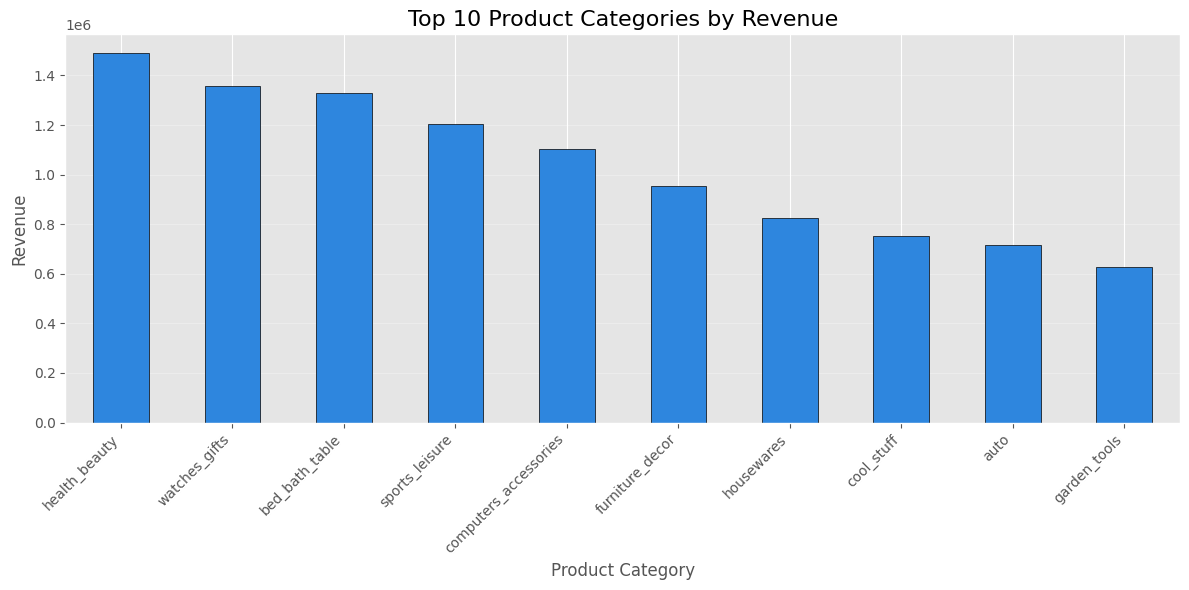

In [14]:
plt.figure(figsize=(12,6))

category_sales.plot(
    kind="bar",
    color="#2E86DE",
    edgecolor="black"
)

plt.title("Top 10 Product Categories by Revenue", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

The highest revenue com### Business Insight

The **Health & Beauty** category is the largest revenue contributor, generating **1,491,398** in sales and contributing **8.96%** of the total revenue.

It is followed by:

| Rank | Category | Revenue | Contribution |
|-----:|-------------------------|-------------:|-------------:|
| 1 | Health & Beauty | 1,491,398 | 8.96% |
| 2 | Watches & Gifts | 1,358,846 | 8.16% |
| 3 | Bed Bath Table | 1,327,662 | 7.98% |
| 4 | Sports & Leisure | 1,205,198 | 7.24% |
| 5 | Computers & Accessories | 1,104,362 | 6.64% |w

Together, the **top five product categories contribute nearly 39% of the total revenue**, indicating that customer demand is highly concentrated in health, lifestyle, home, and technology-related products.

### Business Recommendation

- Prioritize inventory planning for the top-performing categories to minimize stock shortages.
- Allocate larger marketing budgets to these categories, particularly during promotional campaigns and seasonal events.
- Conduct further analysis on lower-performing categories such as **Auto** and **Garden Tools** to identify opportunities for growth through pricing strategies, product assortment, or targeted promotions.es from ...

In [10]:
city = (
    sales.groupby("customer_city")
    ["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

# Business Question 2

## Which cities have the highest number of customers?

Understanding customer distribution helps identify major markets and prioritize sales, logistics, and marketing strategies.

In [15]:
city_customers = (
    sales.groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

In [16]:
city_summary = city_customers.reset_index()

city_summary.columns = [
    "City",
    "Number of Customers"
]

city_summary

,City,Number of Customers
0,sao paulo,14984
1,rio de janeiro,6620
2,belo horizonte,2672
3,brasilia,2069
4,curitiba,1465
5,campinas,1398
6,porto alegre,1326
7,salvador,1209
8,guarulhos,1153
9,sao bernardo do campo,908


In [17]:
total_customer = sales["customer_unique_id"].nunique()

city_summary["Contribution (%)"] = (
    city_summary["Number of Customers"]
    / total_customer
    *100
).round(2)

city_summary

,City,Number of Customers,Contribution (%)
0,sao paulo,14984,15.59
1,rio de janeiro,6620,6.89
2,belo horizonte,2672,2.78
3,brasilia,2069,2.15
4,curitiba,1465,1.52
5,campinas,1398,1.45
6,porto alegre,1326,1.38
7,salvador,1209,1.26
8,guarulhos,1153,1.20
9,sao bernardo do campo,908,0.94


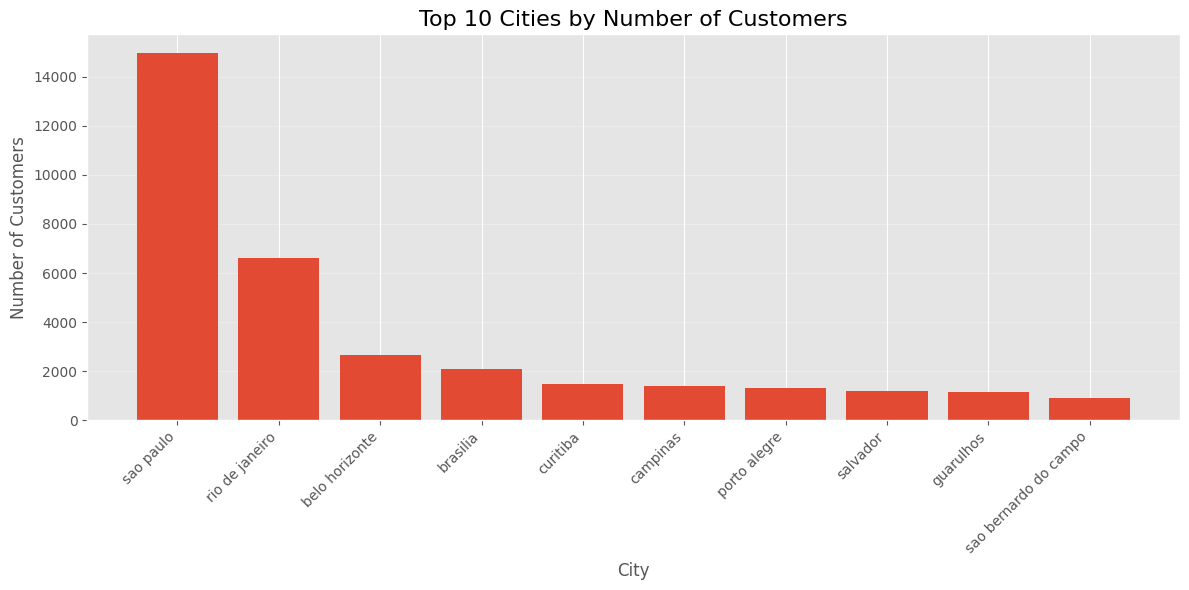

In [18]:
plt.figure(figsize=(12,6))

plt.bar(
    city_summary["City"],
    city_summary["Number of Customers"]
)

plt.title(
    "Top 10 Cities by Number of Customers",
    fontsize=16
)

plt.xlabel("City")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [20]:
city_summary.style.hide(axis="index")

City,Number of Customers,Contribution (%)
sao paulo,14984,15.590000
rio de janeiro,6620,6.890000
belo horizonte,2672,2.780000
brasilia,2069,2.150000
curitiba,1465,1.520000
campinas,1398,1.450000
porto alegre,1326,1.380000
salvador,1209,1.260000
guarulhos,1153,1.200000
sao bernardo do campo,908,0.940000


In [21]:
top10_customer = city_summary["Contribution (%)"].sum()

print(f"Top 10 Cities Contribution : {top10_customer:.2f}%")

Top 10 Cities Contribution : 35.16%


### Business Insight

The customer distribution analysis shows that **São Paulo** is the company's largest market, with **14,984 unique customers**, accounting for **15.59%** of the total customer base.

**Rio de Janeiro** ranks second with **6,620 customers (6.89%)**, followed by **Belo Horizonte** with **2,672 customers (2.78%)**. The significant gap between São Paulo and the remaining cities indicates that customer acquisition is highly concentrated in Brazil's largest metropolitan area.

Overall, the **top 10 cities contribute 35.16% of all customers**, meaning that more than one-third of the company's customers are concentrated in only ten cities. This suggests that urban regions are the primary drivers of the company's customer base and overall sales performance.

### Business Recommendation

Based on the customer distribution analysis, the following recommendations are proposed:

- **Strengthen customer retention** in São Paulo through loyalty programs, personalized promotions, and exclusive offers, as it represents the company's largest customer market.

- **Improve logistics and fulfillment operations** in São Paulo and Rio de Janeiro to maintain customer satisfaction and support high order volumes.

- **Expand marketing campaigns** in medium-sized cities such as Belo Horizonte, Brasília, Curitiba, and Campinas, where customer growth potential remains significant.

- **Increase market penetration** in lower-contributing cities through targeted digital advertising, localized promotions, and strategic partnerships to diversify the customer base and reduce dependence on major metropolitan areas.